In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("llm_price_performance_tracker_2026-03-31.csv")
df.head()

,model_name,model_slug,provider,provider_slug,aa_id,aa_intelligence_index,aa_coding_index,aa_math_index,composite_benchmark,mmlu_pro,...,arena_elo_ci95,arena_votes,parameter_count,release_year,is_open_source,intelligence_per_dollar,price_performance_ratio,elo_benchmark_blend,speed_per_dollar,scrape_date
0,GPT-5.4 (xhigh),gpt-5-4,OpenAI,openai,a89c4b28-2d8c-456e-88ea-255fb51fd2b6,57.2,57.3,NaN,63.40,NaN,...,8.0,5618.0,500.0,2026.0,False,10.17,33.53,80.68,15.94,2026-03-31
1,Gemini 3.1 Pro Preview,gemini-3-1-pro-preview,Google,google,bbd93ebe-80da-4594-bb19-61e69d0331df,57.2,55.5,NaN,65.90,NaN,...,6.0,15809.0,NaN,2026.0,False,12.71,38.66,96.02,26.71,2026-03-31
2,GPT-5.3 Codex (xhigh),gpt-5-3-codex,OpenAI,openai,59b5b14b-5365-4ee7-824a-18a8e6309644,54.0,53.1,NaN,61.53,NaN,...,NaN,NaN,500.0,2026.0,False,11.22,34.96,NaN,19.01,2026-03-31
3,"Claude Opus 4.6 (Adaptive Reasoning, Max Effort)",claude-opus-4-6-adaptive,Anthropic,anthropic,53c98840-47af-49aa-94e6-469fb17e9a1b,53.0,48.1,NaN,59.40,NaN,...,NaN,NaN,NaN,2025.0,False,5.30,24.77,NaN,6.06,2026-03-31
4,"Claude Sonnet 4.6 (Adaptive Reasoning, Max Eff...",claude-sonnet-4-6-adaptive,Anthropic,anthropic,df8d14e0-3997-4e4d-b4ad-9c047acc9c69,51.7,50.9,NaN,54.77,NaN,...,NaN,NaN,NaN,2025.0,False,8.62,28.14,NaN,12.90,2026-03-31


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453 entries, 0 to 452
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   model_name                453 non-null    object 
 1   model_slug                453 non-null    object 
 2   provider                  453 non-null    object 
 3   provider_slug             453 non-null    object 
 4   aa_id                     453 non-null    object 
 5   aa_intelligence_index     446 non-null    float64
 6   aa_coding_index           356 non-null    float64
 7   aa_math_index             268 non-null    float64
 8   composite_benchmark       433 non-null    float64
 9   mmlu_pro                  344 non-null    float64
 10  gpqa_diamond              424 non-null    float64
 11  humanitys_last_exam       420 non-null    float64
 12  livecodebench             342 non-null    float64
 13  scicode                   418 non-null    float64
 14  math_500  

In [4]:
df.describe()

,aa_intelligence_index,aa_coding_index,aa_math_index,composite_benchmark,mmlu_pro,gpqa_diamond,humanitys_last_exam,livecodebench,scicode,math_500,...,time_to_first_answer_s,chatbot_arena_elo,arena_elo_ci95,arena_votes,parameter_count,release_year,intelligence_per_dollar,price_performance_ratio,elo_benchmark_blend,speed_per_dollar
count,446.000000,356.000000,268.000000,433.000000,344.000000,424.000000,420.000000,342.000000,418.000000,201.000000,...,279.000000,46.000000,46.000000,46.000000,286.000000,292.000000,297.000000,295.000000,46.00000,263.000000
mean,21.241256,19.507022,50.358209,43.885358,0.695875,0.597344,0.089479,0.444488,0.282156,0.763821,...,13.234559,1441.586957,5.500000,28526.456522,168.665734,2025.304795,56.694377,132.377085,45.59087,652.151863
std,11.969957,12.756695,30.683282,15.960437,0.167493,0.193779,0.074591,0.250330,0.126316,0.218255,...,21.447354,23.408997,1.929306,23704.998901,234.257631,0.853280,80.906908,140.634859,22.16947,2010.831957
min,4.700000,0.000000,0.000000,4.100000,0.055000,0.098000,0.012000,0.002000,0.000000,0.059000,...,0.199000,1412.000000,3.000000,2860.000000,0.600000,2023.000000,0.100000,9.730000,13.51000,0.790000
25%,12.000000,10.000000,23.350000,33.670000,0.633750,0.433750,0.044000,0.235750,0.193250,0.677000,...,0.582000,1422.000000,4.000000,11526.250000,9.250000,2025.000000,10.760000,42.620000,26.02250,38.315000
50%,17.950000,16.650000,52.800000,45.720000,0.752000,0.623000,0.055500,0.423000,0.295500,0.835000,...,1.551000,1436.500000,5.000000,20967.000000,49.000000,2026.000000,29.700000,82.940000,42.54500,119.170000
75%,28.475000,28.750000,79.475000,53.860000,0.814250,0.764000,0.103000,0.667500,0.377000,0.939000,...,18.249000,1454.000000,6.000000,38311.500000,235.000000,2026.000000,70.340000,174.565000,63.39500,473.960000
max,57.200000,57.300000,99.000000,95.400000,0.898000,0.941000,0.447000,0.917000,0.589000,0.994000,...,159.489000,1500.000000,11.000000,103891.000000,1200.000000,2026.000000,525.000000,1135.680000,96.02000,20735.850000


In [5]:
len(df.index)

453

In [6]:
df.isnull().sum()

model_name                    0
model_slug                    0
provider                      0
provider_slug                 0
aa_id                         0
aa_intelligence_index         7
aa_coding_index              97
aa_math_index               185
composite_benchmark          20
mmlu_pro                    109
gpqa_diamond                 29
humanitys_last_exam          33
livecodebench               111
scicode                      35
math_500                    252
aime_2025                   259
input_cost_usd_per_1m       138
output_cost_usd_per_1m      138
blended_cost_usd_per_1m     138
pricing_tier                  0
output_tokens_per_second    174
time_to_first_token_s       174
time_to_first_answer_s      174
chatbot_arena_elo           407
arena_elo_ci95              407
arena_votes                 407
parameter_count             167
release_year                161
is_open_source                0
intelligence_per_dollar     156
price_performance_ratio     158
elo_benc

In [7]:
keep_cols = [
    'model_name', 'provider', 'is_open_source', 'release_year',
    'aa_intelligence_index', 'aa_coding_index', 'aa_math_index', 
    'composite_benchmark', 'mmlu_pro', 'gpqa_diamond', 
    'humanitys_last_exam', 'livecodebench', 'scicode', 
    'math_500', 'aime_2025', 'input_cost_usd_per_1m', 
    'output_cost_usd_per_1m', 'blended_cost_usd_per_1m', 
    'pricing_tier', 'output_tokens_per_second'
]

df_clean= df[keep_cols].copy()

# 3. Optional: Verify the result
print(df_clean.isnull().sum())


model_name                    0
provider                      0
is_open_source                0
release_year                161
aa_intelligence_index         7
aa_coding_index              97
aa_math_index               185
composite_benchmark          20
mmlu_pro                    109
gpqa_diamond                 29
humanitys_last_exam          33
livecodebench               111
scicode                      35
math_500                    252
aime_2025                   259
input_cost_usd_per_1m       138
output_cost_usd_per_1m      138
blended_cost_usd_per_1m     138
pricing_tier                  0
output_tokens_per_second    174
dtype: int64


In [8]:
# Calculate mean intelligence and ignore NAN
df['aa_intelligence_index'].mean()


#Convert release_year into datetime format and fill other days to 0
df['release_year'] = df['release_year'].fillna(0).astype('Int64')

# 1. Identify top-10 providers by model count and create bar chart on the count of their models.

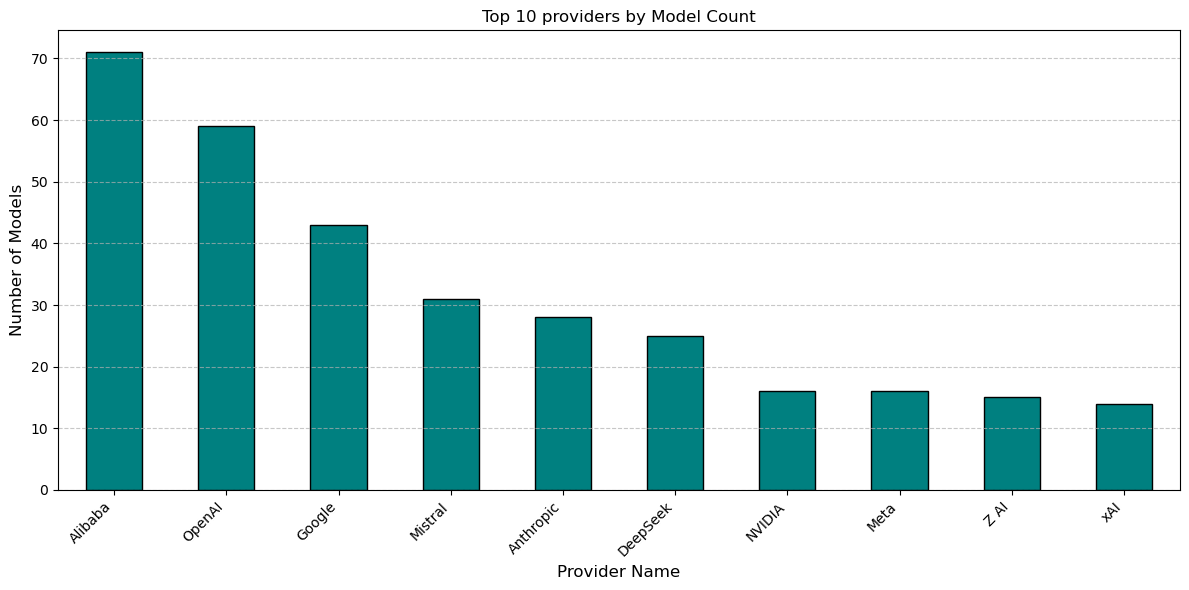

provider
Alibaba      71
OpenAI       59
Google       43
Mistral      31
Anthropic    28
DeepSeek     25
NVIDIA       16
Meta         16
Z AI         15
xAI          14
Name: count, dtype: int64


In [9]:
top10Providers = df['provider'].value_counts().head(10)

plt.figure(figsize=(12,6))
top10Providers.plot(kind='bar',color='teal',edgecolor='black')

plt.title('Top 10 providers by Model Count')
plt.xlabel('Provider Name', fontsize=12)
plt.ylabel('Number of Models', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate labels so they don't overlap
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print(top10Providers)

# 2 A box plot of intelligence distribution of different models by pricing tier.

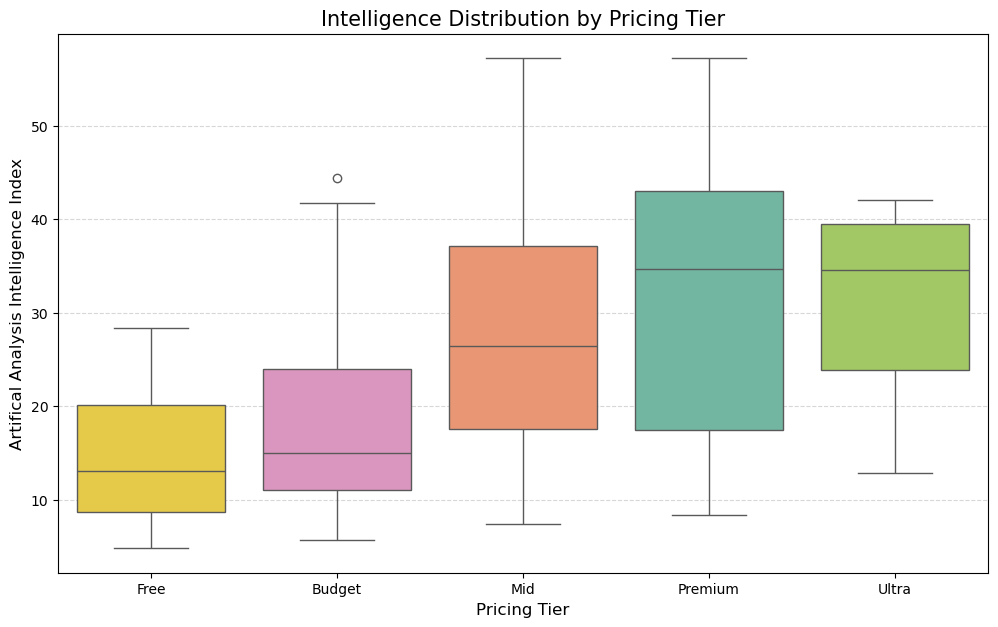

In [10]:
tiers = ['Free', 'Budget', 'Mid', 'Premium', 'Ultra']

plt.figure(figsize=(12,7))
sns.boxplot(x='pricing_tier', y='aa_intelligence_index', data=df, order=tiers,palette='Set2', legend=False, hue='pricing_tier')

plt.title('Intelligence Distribution by Pricing Tier', fontsize=15)
plt.xlabel('Pricing Tier', fontsize=12)
plt.ylabel('Artifical Analysis Intelligence Index', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# Find top-5 models on 5 benchmarks  (GPQA Diamond','Humanity's Last Exam','LiveCode Bench','SciCode','MATH-500')

In [11]:
benchmarks = ['gpqa_diamond', 'humanitys_last_exam', 'livecodebench', 'scicode', 'math_500']
results =[]
for bench in benchmarks:
    top_models = df.dropna(subset=[bench]).nlargest(5, bench)[['model_name', bench]]
    print(top_models.to_string(index=False, justify='left'))
    print(f"\n{"="*80}")
    

model_name                   gpqa_diamond
     Gemini 3.1 Pro Preview 0.941        
            GPT-5.4 (xhigh) 0.920        
      GPT-5.3 Codex (xhigh) 0.915        
Gemini 3 Pro Preview (high) 0.908        
            GPT-5.2 (xhigh) 0.903        

model_name                                        humanitys_last_exam
                          Gemini 3.1 Pro Preview 0.447               
                                 GPT-5.4 (xhigh) 0.416               
                           GPT-5.3 Codex (xhigh) 0.399               
                     Gemini 3 Pro Preview (high) 0.372               
Claude Opus 4.6 (Adaptive Reasoning, Max Effort) 0.367               

model_name                          livecodebench
       Gemini 3 Pro Preview (high) 0.917         
Gemini 3 Flash Preview (Reasoning) 0.908         
            DeepSeek V3.2 Speciale 0.896         
                  GPT-5.2 (medium) 0.894         
               GLM-4.7 (Reasoning) 0.894         

model_name               

In [19]:
from sklearn.ensemble import RandomForestRegressor

# Prepare features and target
feature_cols = [
    'is_open_source',
    'release_year',
    'aa_intelligence_index', # composite of 10 evaluations (the master calculation of all metrics)
    'output_tokens_per_second'
]

target = 'blended_cost_usd_per_1m'

# Create clean modeling subset
df_model = df.dropna(subset=feature_cols + [target]).copy()
df_model['is_open_source'] = df_model['is_open_source'].astype(int)

#split
X = df_model[feature_cols]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"R^2 Score: {r2}")


df_model['predicted_cost'] = model.predict(X)

top3 = df_model[['model_name', 'predicted_cost']].sort_values(by='predicted_cost', ascending=False).head(3)

print(top3)

Mean Squared Error (MSE): 1.3180380628845219
R^2 Score: 0.946512802450582
                          model_name  predicted_cost
314                            GPT-4        31.41226
66   Claude 4.1 Opus (Non-reasoning)        29.30100
50         Claude 4 Opus (Reasoning)        28.12775


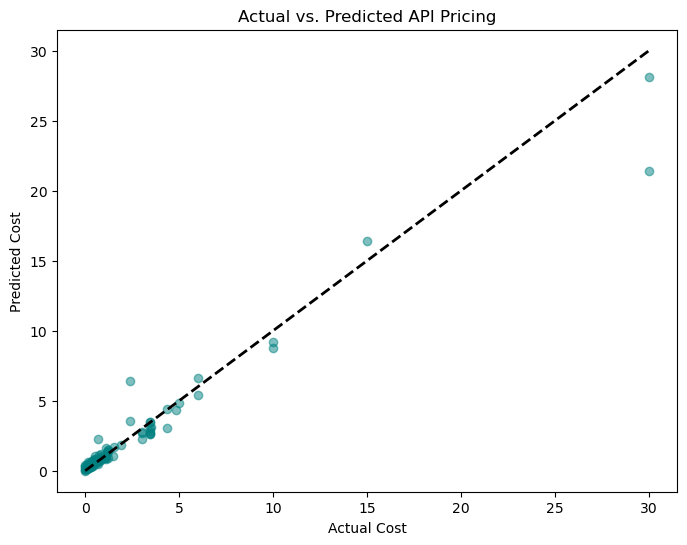

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Cost')
plt.ylabel('Predicted Cost')
plt.title('Actual vs. Predicted API Pricing')
plt.show()

# Temporal Capability Tracking

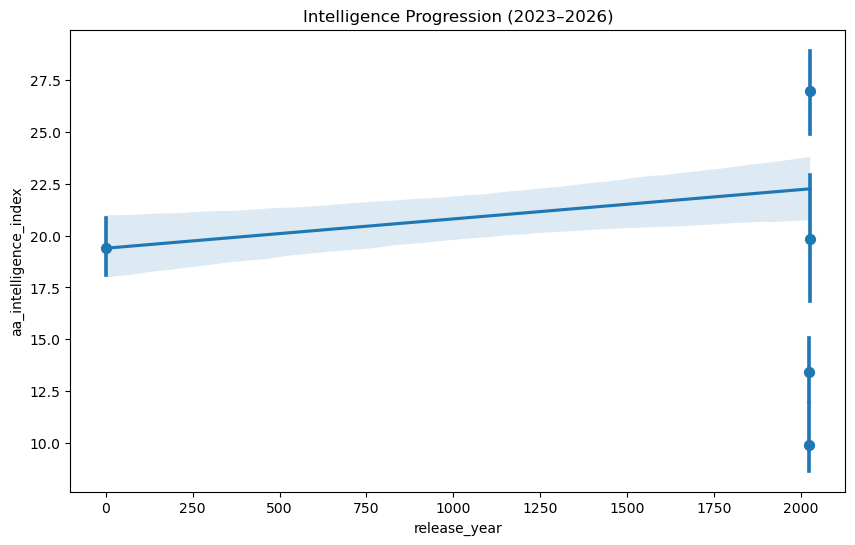

In [21]:
plt.figure(figsize=(10, 6))
sns.regplot(x='release_year', y='aa_intelligence_index', data=df, x_estimator=np.mean)
plt.title('Intelligence Progression (2023–2026)')
plt.show()

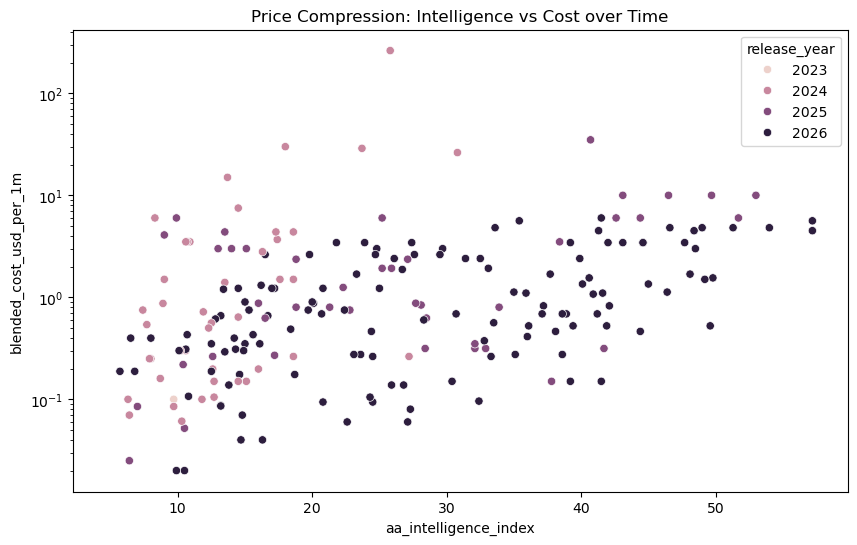

In [24]:

df_known_years = df[df['release_year'] > 0].copy()
plt.figure(figsize=(10, 6))
sns.scatterplot(x='aa_intelligence_index', y='blended_cost_usd_per_1m', hue='release_year', data=df_known_years)
plt.yscale('log')
plt.title('Price Compression: Intelligence vs Cost over Time')
plt.show()